# <center>Customer Segmentation with K-Means Algorithm</center>

#### <center>GROUP 1 | K-Means 1 </center>

The dataset used for this Machine Learning activity is sourced from Kaggle, which contains transaction records from a UK-based online gift store between December 2010 and December 2011. It includes information such as item descriptions, quantities, prices, purchase dates, and customer IDs. **The dataset will be used for customer segmentation using K-Means clustering to help businesses understand and target different set of customers.**

Dataset Source: https://www.kaggle.com/datasets/hellbuoy/online-retail-customer-clustering/data

<p>
  <img src="https://media.istockphoto.com/id/1175445207/vector/shopping-people.jpg?s=612x612&w=0&k=20&c=GybUaC0wmcbI2_obGpJe4bARvN65e4TaVsmJIT8aWXA=" alt="Online Retail" width="400"/>
</p>

---

## What is K-Means Algorithm?

**K-means Clustering** is an unsupervised learning algorithm where unlabeled data with similar characteristics are grouped into clusters. It works well with **<u>numeric and continuous data</u>** as it deals with distance calculations. This algorithm is commonly used in applications like customer segmentation, pattern recognition, and image compression. It's popular because it's simple, fast, and effective when the data naturally falls into distinct groups. The main idea is to divide the dataset into k clusters, where each point belongs to the group with the closest average value (centroid).



### How It Works
Here’s a step-by-step look at how K-means clustering works:

1. Choose how many clusters you want. This number is called `k`.

2. Pick k random points in your data as the starting “centroids” or center points of each cluster.

3. Assign each data point to the nearest centroid based on distance (usually Euclidean distance).

4. Recalculate the centroids by finding the average location of all the points assigned to each cluster.

5. Repeat steps 3 and 4 until the centroids stop changing significantly or a set number of iterations is reached.

In the end, the algorithm forms `k` clusters, where each group contains points that are more similar to each other than to those in other groups.


### Pros and Cons

#### Pros:
- Easy to understand and implement.
- Works really fast with large amounts of data.
- Works effectively when the clusters in the data are clearly separated.
- Can be used in many real-world applications such as customer grouping or image compression.

#### Cons:
- You have to decide the number of clusters (k) before running it, which isn’t always obvious.
- It can be affected by outliers or noise in the data.
- Assumes that all clusters are roughly the same size and shape.
- Results can vary depending on how the starting centroids are chosen.

### References:
<ul>Kavlakoglu, E., & Winland, V. (n.d.). <i>What is k-means clustering?</i> IBM. https://www.ibm.com/think/topics/k-means-clustering </ul>

---

# <center> K-Means Clustering Implementation </center>

## 1. Data Preprocessing

### Loading and Viewing the Data

In [1]:
import pandas as pd

df = pd.read_csv('C:/Users/Faith/Downloads/OnlineRetail.csv', encoding='ISO-8859-1')

In [2]:
# Show the first few rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


### Data Inspection

- #### Checking Data Types

In [3]:
# Check structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.shape

(541909, 8)

- #### Checking Missing Values

In [5]:
# Check missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

> The CustomerID column has many missing values, and Description also has a few. We'll need to clean this before clustering.

- #### Checking Duplicates

In [6]:
# Check total number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# View duplicate rows (optional)
df[df.duplicated()]

Number of duplicate rows: 5268


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,01-12-2010 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,01-12-2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,01-12-2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,01-12-2010 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,01-12-2010 11:49,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,09-12-2011 11:34,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,09-12-2011 11:34,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,09-12-2011 11:34,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,09-12-2011 11:34,2.10,14446.0,United Kingdom


> These repeated rows are not actual duplicates, but represent different products bought in the same transaction. Each row shows a unique item in a customer's order, so removing them would delete valid purchase information. **We'll keep them to preserve the integrity and completeness of each transaction.**

#### Drop Rows with Missing Values and Remove Invalid Transactions (like returns or refunds):

In [7]:
df_clean = df.dropna(subset=['CustomerID'])
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

We keep only valid transactions with complete customer data and positive values, which gives a more accurate view of actual purchases.

#### Add a New Column to Calculate Total Revenue per Line Item:

In [8]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

This helps us understand how much each transaction is worth, which will be useful when grouping customers by total spending later.

---

## 2. Exploratory Data Analysis (EDA)

### Unit Price Distribution

C:\ANACONDA\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


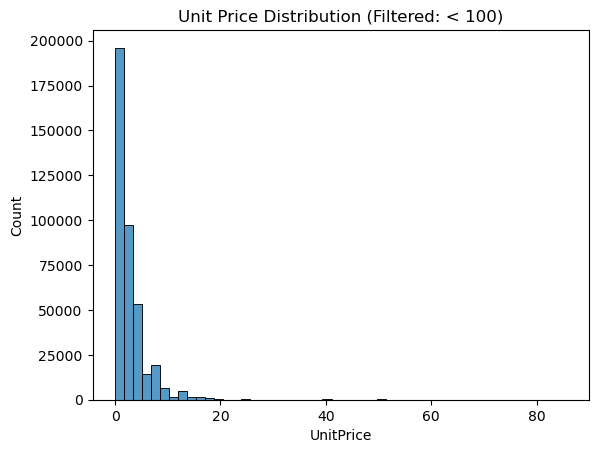

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_clean[df_clean['UnitPrice'] < 100]['UnitPrice'], bins=50)
plt.title('Unit Price Distribution (Filtered: < 100)')
plt.show()

> We filtered out prices above 100 to remove extreme outliers that could distort the visualization, helping us **focus on the typical range of product prices**. We can see that **most products are priced under 10**.

### Top 10 Most Purchased Products

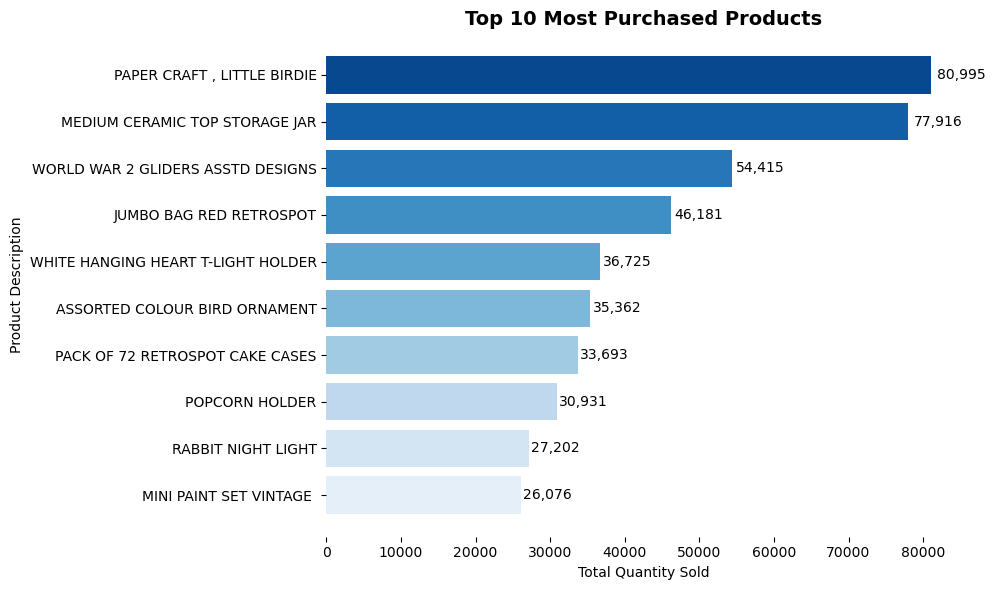

In [10]:
# Get top 10 products by quantity
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Prepare plot
plt.figure(figsize=(10, 6))

# Reverse the color palette so higher values are darker
colors = sns.color_palette("Blues", n_colors=10)[::-1]

# Create horizontal bar plot with reversed colors
bars = plt.barh(top_products.index, top_products.values, color=colors)

# Titles and labels
plt.title('Top 10 Most Purchased Products', fontsize=14, weight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')

# Invert y-axis to show highest at top
plt.gca().invert_yaxis()

# Remove all grid lines and spines
plt.grid(False)
sns.despine(left=True, bottom=True)

# Annotate bars with values
for bar in bars:
    width = bar.get_width()
    plt.text(width + (width * 0.01), bar.get_y() + bar.get_height() / 2,
             f'{int(width):,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

> The graph shows the **top 10 products that were in demand and bought the most**, giving us insight on sales trends.

### Top 10 Countries by Total Revenue

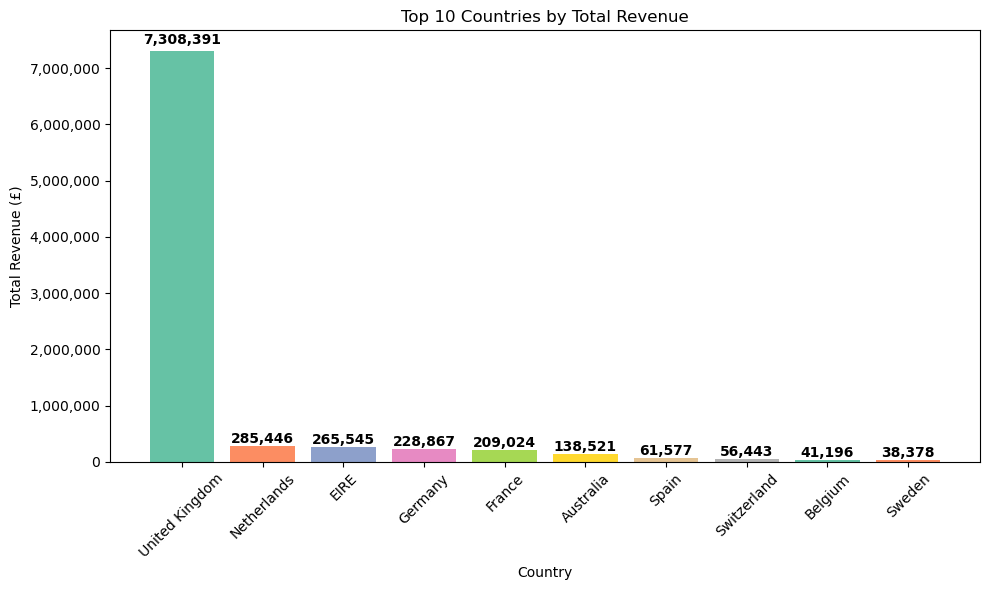

In [11]:
import matplotlib.ticker as ticker

# Calculate total revenue for each line if not already in the data
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Group by country and get top 10 by total revenue
top_countries = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# Use a distinct color for each bar
colors = sns.color_palette('Set2', n_colors=10)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(top_countries.index, top_countries.values, color=colors)

# Titles and labels
ax.set_title('Top 10 Countries by Total Revenue')
ax.set_ylabel('Total Revenue (£)')
ax.set_xlabel('Country')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))  # Comma formatting
plt.xticks(rotation=45)

# Add value labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(i, height + (height * 0.01), f'{int(height):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

> This chart reveals which countries generate the most revenue, suggesting that **most customers are UK-based**. This supports focusing on UK customers for more stable segmentation.

---

## 3. Feature Engineering

### Aggregate Features for Each Customer

In [12]:
# Aggregate features for each customer
customer_df = df_clean.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',           # Total number of purchases
    'Quantity': 'sum',                # Total items purchased
    'TotalPrice': 'sum'               # Total revenue generated
}).rename(columns={
    'InvoiceNo': 'TransactionCount'
}).reset_index()

> We aggregated the data so each row represents a single customer. Now we have one row per customer showing **<u>how often they buy</u> (TransactionCount)**, **<u>how many items they buy</u> (Quantity)**, and **<u>how much they spend</u> (TotalPrice)**, which is ideal for clustering as it captures different types of customer behavior.

In [13]:
customer_df.head()

,CustomerID,TransactionCount,Quantity,TotalPrice
0,12346.0,1,74215,77183.60
1,12347.0,7,2458,4310.00
2,12348.0,4,2341,1797.24
3,12349.0,1,631,1757.55
4,12350.0,1,197,334.40


### Normalize Features

In [14]:
from sklearn.preprocessing import StandardScaler

features = ['TransactionCount', 'Quantity', 'TotalPrice']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df[features])

> We scale the customer features **so they contribute equally to clustering**. K-Means is sensitive to feature scales. Without scaling, features like TotalPrice, which can be large, would dominate the clustering results.

---

## 4. K-Means Clustering

 ### Elbow Method vs Practical Clustering

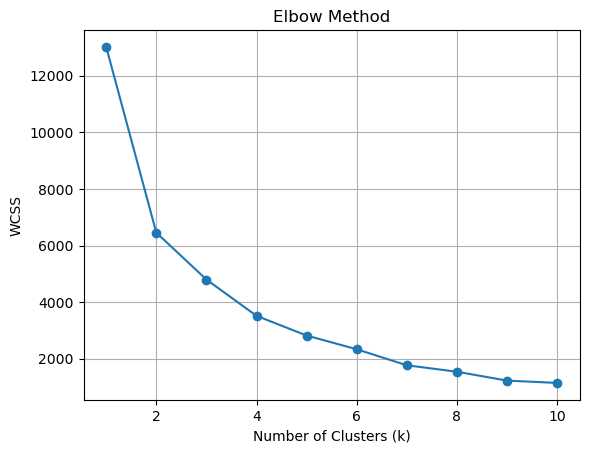

In [15]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid()
plt.show()

> We applied the Elbow Method to determine the most appropriate number of clusters (k) for clustering. Though the elbow point in this case suggested 2 as the most efficient choice, **we opted to use 4 clusters to capture more differences in customer purchasing behavior**. Having only 2 clusters may oversimplify the diversity of customer patterns, where we might only see low or high spenders. In a practical scenario, the number of clusters also depends on the goals of a business. **Having four groups can work better for marketing strategies for diverse customers types.**

### Apply K-Means Algorithm

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

In [17]:
scaled_df = pd.DataFrame(X_scaled, columns=features)
scaled_df['Cluster'] = customer_df['Cluster']

### Cluster Visual Comparison

C:\Users\Faith\AppData\Local\Temp\ipykernel_25760\3075438982.py:11: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.scatterplot(data=customer_df, x='TransactionCount', y='TotalPrice', hue='Cluster',
C:\Users\Faith\AppData\Local\Temp\ipykernel_25760\3075438982.py:18: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.scatterplot(data=customer_df, x='Quantity', y='TotalPrice', hue='Cluster',
C:\Users\Faith\AppData\Local\Temp\ipykernel_25760\3075438982.py:25: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.scatterplot(data=customer_df, x='TransactionCount', y='Quantity', hue='Cluster',
C:\Users\Faith\AppData\Local\Temp\ipykernel_25760\3075438982.py:34: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.scatterplot(data=scaled_df, x='TransactionCount', y='TotalPrice', hue='Cluster',
C:\Users

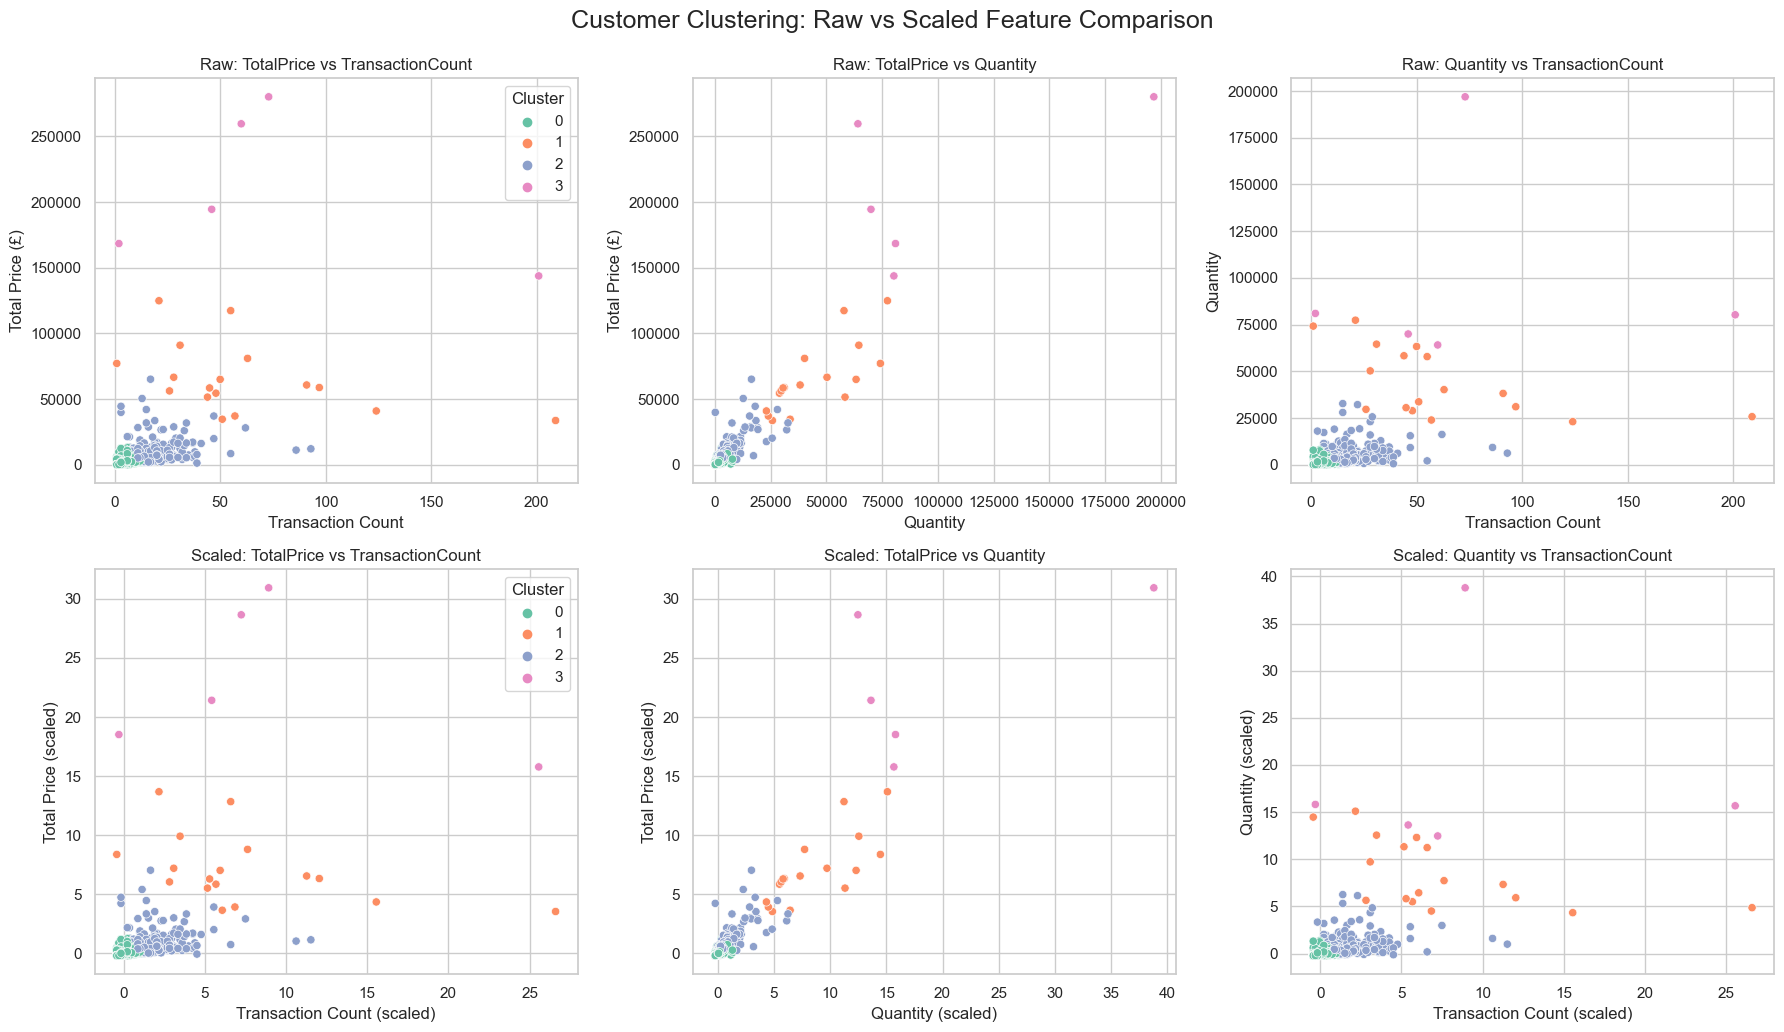

In [18]:
# Set style
sns.set(style="whitegrid")
palette = sns.color_palette("Set2")

# Create 2 rows × 3 columns of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

### ROW 1: Raw data (customer_df)

# Plot 1: TotalPrice vs TransactionCount (Raw)
sns.scatterplot(data=customer_df, x='TransactionCount', y='TotalPrice', hue='Cluster',
                palette=palette, ax=axes[0, 0])
axes[0, 0].set_title('Raw: TotalPrice vs TransactionCount')
axes[0, 0].set_xlabel('Transaction Count')
axes[0, 0].set_ylabel('Total Price (£)')

# Plot 2: TotalPrice vs Quantity (Raw)
sns.scatterplot(data=customer_df, x='Quantity', y='TotalPrice', hue='Cluster',
                palette=palette, ax=axes[0, 1], legend=False)
axes[0, 1].set_title('Raw: TotalPrice vs Quantity')
axes[0, 1].set_xlabel('Quantity')
axes[0, 1].set_ylabel('Total Price (£)')

# Plot 3: Quantity vs TransactionCount (Raw)
sns.scatterplot(data=customer_df, x='TransactionCount', y='Quantity', hue='Cluster',
                palette=palette, ax=axes[0, 2], legend=False)
axes[0, 2].set_title('Raw: Quantity vs TransactionCount')
axes[0, 2].set_xlabel('Transaction Count')
axes[0, 2].set_ylabel('Quantity')

### ROW 2: Scaled data (scaled_df)

# Plot 4: TotalPrice vs TransactionCount (Scaled)
sns.scatterplot(data=scaled_df, x='TransactionCount', y='TotalPrice', hue='Cluster',
                palette=palette, ax=axes[1, 0])
axes[1, 0].set_title('Scaled: TotalPrice vs TransactionCount')
axes[1, 0].set_xlabel('Transaction Count (scaled)')
axes[1, 0].set_ylabel('Total Price (scaled)')

# Plot 5: TotalPrice vs Quantity (Scaled)
sns.scatterplot(data=scaled_df, x='Quantity', y='TotalPrice', hue='Cluster',
                palette=palette, ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Scaled: TotalPrice vs Quantity')
axes[1, 1].set_xlabel('Quantity (scaled)')
axes[1, 1].set_ylabel('Total Price (scaled)')

# Plot 6: Quantity vs TransactionCount (Scaled)
sns.scatterplot(data=scaled_df, x='TransactionCount', y='Quantity', hue='Cluster',
                palette=palette, ax=axes[1, 2], legend=False)
axes[1, 2].set_title('Scaled: Quantity vs TransactionCount')
axes[1, 2].set_xlabel('Transaction Count (scaled)')
axes[1, 2].set_ylabel('Quantity (scaled)')

# Adjust layout
plt.tight_layout()
plt.suptitle('Customer Clustering: Raw vs Scaled Feature Comparison', fontsize=18, y=1.03)
plt.show()

#### Raw vs Scaled Visualization
> We visualized both raw and scaled data to **validate that scaling preserves clustering patterns** while ensuring features contribute equally in K-Means, which is sensitive to scale. Raw data shows true values but can bias clustering due to varying scales. Scaled plots confirm that relationships and cluster separations remain consistent, justifying the use of StandardScaler for fair distance calculations and reliable customer segmentation.


### Summary of the Average Behavior of Each Customer Cluster

In [19]:
customer_df.groupby('Cluster')[['TransactionCount', 'Quantity', 'TotalPrice']].mean().round(2)

,TransactionCount,Quantity,TotalPrice
Cluster,,,
0,2.97,621.74,1045.10
1,61.24,44177.24,65307.42
2,18.80,5184.54,9294.43
3,76.40,98458.80,209342.33


---

## <center>K-Means Clustering Results: Customer Segmentation</center>

### Purpose: To Understand Different Customer Types Based on Purchasing Behavior

We applied **K-Means Clustering** to group customers using three key features:
- `TransactionCount`: how often they purchase
- `Quantity`: how many items they buy
- `TotalPrice`: how much they spend

This resulted in **4 customer segments**, each with distinct behaviors.

---

### Cluster Summary (Mean Values):

| Cluster | Transactions | Quantity   | Total Spend (£) |
|---------|--------------|------------|-----------------|
| **0**   | 2.97         | 621.74     | 1,045.10        |
| **1**   | 61.24        | 44,177.24  | 65,307.42       |
| **2**   | 18.80        | 5,184.54   | 9,294.43        |
| **3**   | 76.40        | 98,458.80  | 209,342.33      |

---

### Segment Interpretation:

#### 🟡 Cluster 0 – *Occasional Buyers*
- Occasional customers with low engagement
- May be seasonal or one-time shoppers

#### 🔵 Cluster 1 – *Loyal Buyers*
- Consistently buy in moderate to high volume
- Likely loyal customers or small businesses

#### 🟢 Cluster 2 – *Regular Buyers*
- Moderate frequency and spend
- Good candidates for **upselling or loyalty incentives**

#### 🟣 Cluster 3 – *High Bulk Buyers*
- High transaction count and massive item volume
- Likely **resellers or institutional clients**
- Priority group for **retention and VIP treatment**

---

### Business Use Cases:
- **Retention:** Focus on Cluster 3 and 1
- **Marketing:** Re-engage Cluster 0 with promos
- **Upsell:** Offer deals to Cluster 2 to increase value